## 1-3) Подготовка среды

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
DATA_DIR = "./data"

ARTIFACTS_DIR = Path("./artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 128
DATASET_NAME = "EMNIST"
NUM_CLASSES = 47

## 4-12) Загрузка и подготовка данных

In [4]:
transform = transforms.ToTensor()

In [5]:
full_train_dataset = datasets.EMNIST(
    root=DATA_DIR,
    split="balanced",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.EMNIST(
    root=DATA_DIR,
    split="balanced",
    train=False,
    download=True,
    transform=transform
)

In [6]:
len(full_train_dataset), len(test_dataset)

(112800, 18800)

In [7]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

In [8]:
len(train_dataset), len(val_dataset), len(test_dataset)

(90240, 22560, 18800)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
x_batch, y_batch = next(iter(train_loader))
x_batch.shape, y_batch.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [11]:
x_batch.min().item(), x_batch.max().item()

(0.0, 1.0)

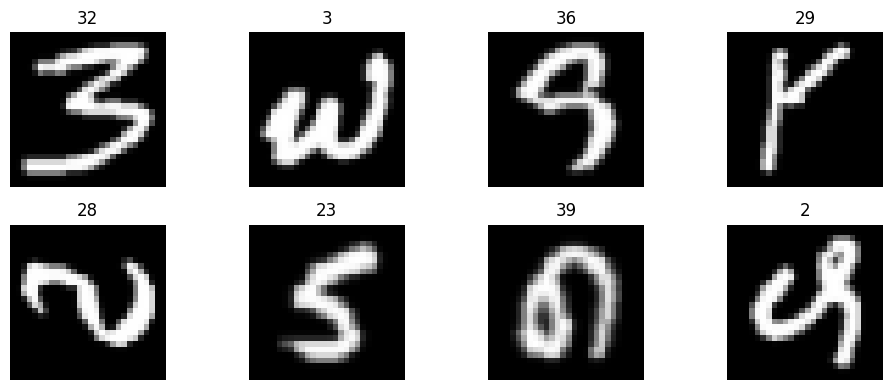

In [12]:
plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_batch[i].squeeze(0), cmap="gray")
    plt.title(str(y_batch[i].item()))
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13-20) Модель MLP и базовые функции обучения

In [13]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim=28 * 28,
        num_classes=47,
        hidden_sizes=(256, 128),
        dropout=0.0,
        use_batchnorm=False
    ):
        super().__init__()

        layers = []
        in_features = input_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(in_features, hidden_size))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = hidden_size

        layers.append(nn.Linear(in_features, num_classes))

        self.flatten = nn.Flatten()
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        x = self.net(x)
        return x

In [14]:
model = MLP(
    input_dim=28 * 28,
    num_classes=NUM_CLASSES,
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=False
).to(device)

model

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=47, bias=True)
  )
)

In [15]:
with torch.no_grad():
    logits = model(x_batch.to(device))

logits.shape

torch.Size([128, 47])

In [16]:
def compute_accuracy(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

In [18]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            batch_size = y.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

In [19]:
model = MLP(
    input_dim=28 * 28,
    num_classes=NUM_CLASSES,
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=False
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [20]:
train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
val_loss, val_acc = evaluate(model, val_loader, criterion, device)

train_loss, train_acc, val_loss, val_acc

(1.2720746395435738, 0.642331560283688, 0.8129239954001515, 0.7548758865248227)

## 21-28) Универсальный pipeline обучения

In [21]:
def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    early_stopping=False,
    patience=3
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state_dict = None

    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if early_stopping and epochs_without_improvement >= patience:
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return {
        "history": history,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "epochs_trained": len(history["train_loss"]),
        "best_state_dict": best_state_dict
    }

In [22]:
def plot_history(history, title=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    if title:
        plt.title(title)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    if title:
        plt.title(title)

    plt.tight_layout()
    plt.show()

In [23]:
model = MLP(
    input_dim=28 * 28,
    num_classes=NUM_CLASSES,
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=False
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

result = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=5,
    early_stopping=False
)

In [24]:
result["best_val_acc"], result["best_val_loss"], result["epochs_trained"]

(0.8274379432624114, 0.5379185394192418, 5)

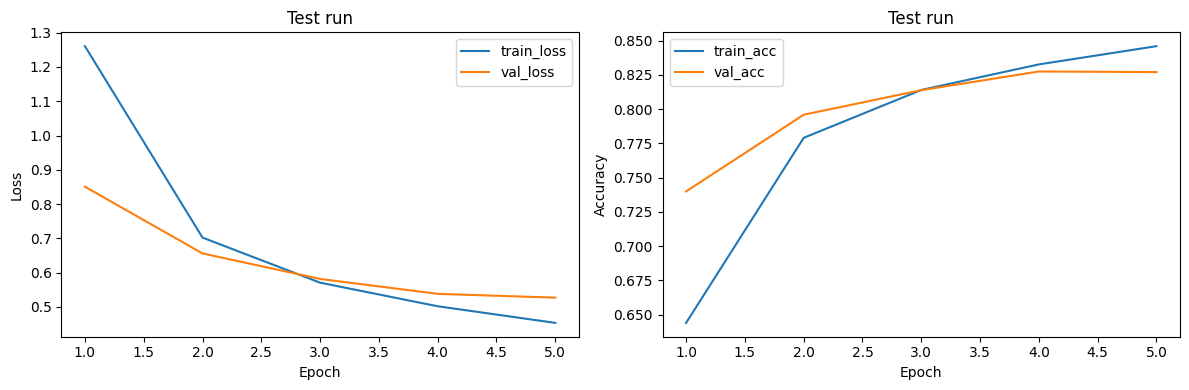

In [25]:
plot_history(result["history"], title="Test run")

In [26]:
runs = []

In [27]:
def make_model_summary(hidden_sizes, dropout, use_batchnorm):
    return (
        f"hidden_sizes={list(hidden_sizes)}, "
        f"activation=ReLU, "
        f"dropout={dropout}, "
        f"batchnorm={use_batchnorm}"
    )

In [28]:
def run_experiment(
    experiment_id,
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False,
    patience=3
):
    model = MLP(
        input_dim=28 * 28,
        num_classes=NUM_CLASSES,
        hidden_sizes=hidden_sizes,
        dropout=dropout,
        use_batchnorm=use_batchnorm
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )
    else:
        raise ValueError("Unsupported optimizer")

    result = fit_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=epochs,
        early_stopping=early_stopping,
        patience=patience
    )

    run_info = {
        "experiment_id": experiment_id,
        "dataset": DATASET_NAME,
        "seed": SEED,
        "model_summary": make_model_summary(hidden_sizes, dropout, use_batchnorm),
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": result["epochs_trained"],
        "best_val_accuracy": result["best_val_acc"],
        "best_val_loss": result["best_val_loss"]
    }

    runs.append(run_info)

    return {
        "model": model,
        "result": result,
        "run_info": run_info
    }

## 29-34) Эксперименты регуляризации

In [29]:
e1 = run_experiment(
    experiment_id="E1",
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False
)

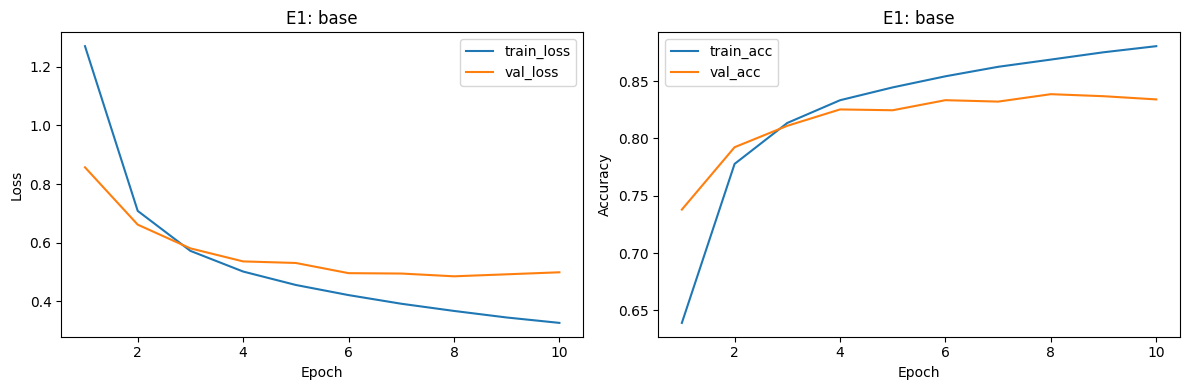

In [30]:
plot_history(e1["result"]["history"], title="E1: base")

In [31]:
e2 = run_experiment(
    experiment_id="E2",
    hidden_sizes=(256, 128),
    dropout=0.3,
    use_batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False
)

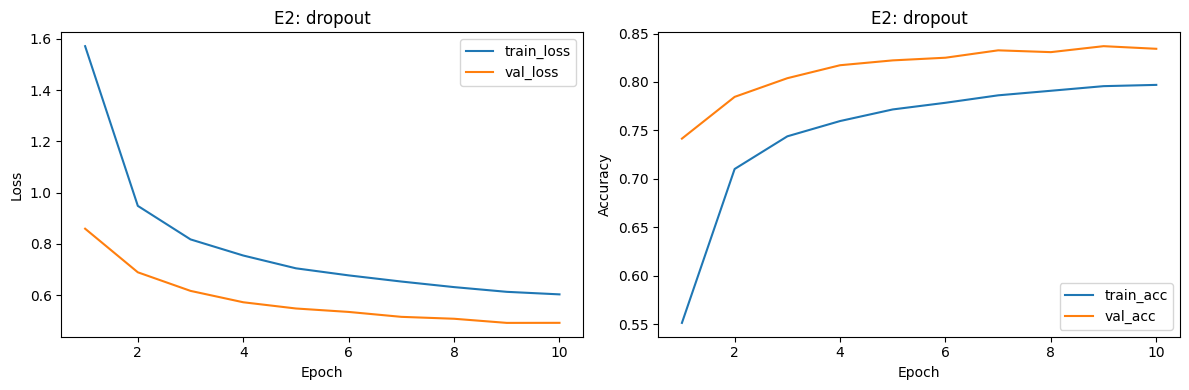

In [32]:
plot_history(e2["result"]["history"], title="E2: dropout")

In [33]:
e3 = run_experiment(
    experiment_id="E3",
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=True,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=10,
    early_stopping=False
)

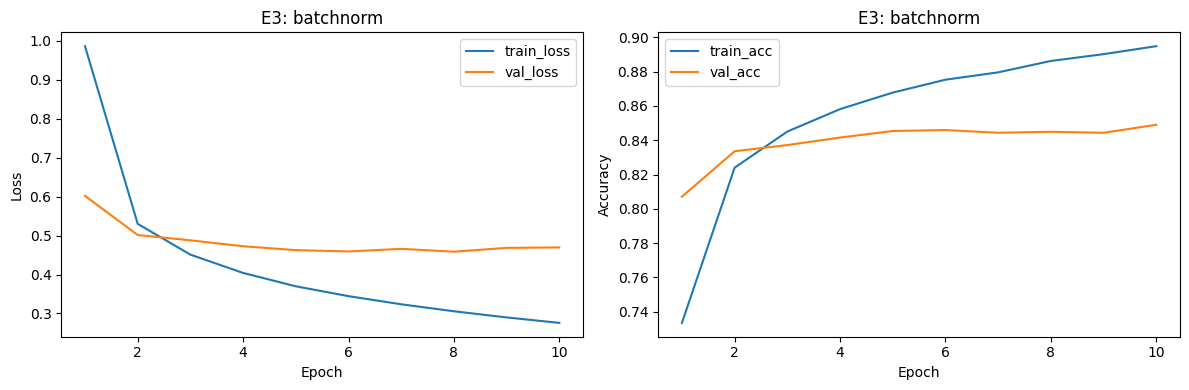

In [34]:
plot_history(e3["result"]["history"], title="E3: batchnorm")

## 35-42) Выбор лучшей модели

In [35]:
e1["run_info"]["best_val_accuracy"], e2["run_info"]["best_val_accuracy"], e3["run_info"]["best_val_accuracy"]

(0.8385195035460993, 0.8369237588652483, 0.8490248226950354)

In [36]:
if e2["run_info"]["best_val_accuracy"] >= e3["run_info"]["best_val_accuracy"]:
    best_regularized_config = {
        "hidden_sizes": (256, 128),
        "dropout": 0.3,
        "use_batchnorm": False
    }
    best_regularized_source = "E2"
else:
    best_regularized_config = {
        "hidden_sizes": (256, 128),
        "dropout": 0.0,
        "use_batchnorm": True
    }
    best_regularized_source = "E3"

best_regularized_source, best_regularized_config

('E3', {'hidden_sizes': (256, 128), 'dropout': 0.0, 'use_batchnorm': True})

In [37]:
e4 = run_experiment(
    experiment_id="E4",
    hidden_sizes=best_regularized_config["hidden_sizes"],
    dropout=best_regularized_config["dropout"],
    use_batchnorm=best_regularized_config["use_batchnorm"],
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    epochs=15,
    early_stopping=True,
    patience=4
)

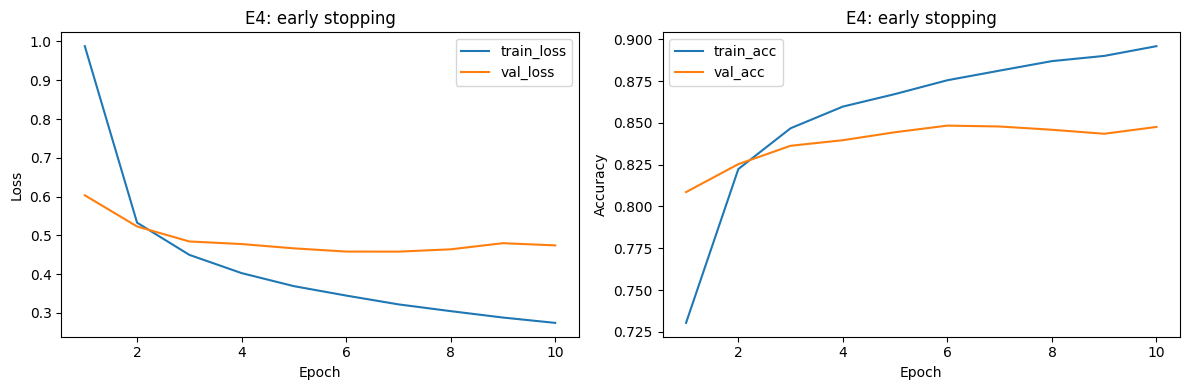

In [38]:
plot_history(e4["result"]["history"], title="E4: early stopping")

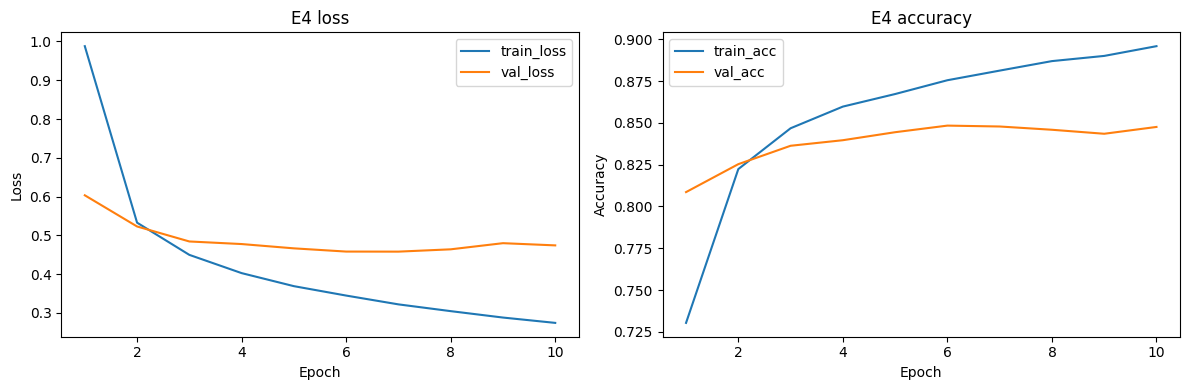

In [39]:
history = e4["result"]["history"]
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("E4 loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train_acc")
plt.plot(epochs, history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("E4 accuracy")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "curves_best.png", bbox_inches="tight")
plt.show()

In [40]:
torch.save(e4["model"].state_dict(), ARTIFACTS_DIR / "best_model.pt")

In [41]:
best_config = {
    "experiment_id": "E4",
    "source_model": best_regularized_source,
    "dataset": DATASET_NAME,
    "seed": SEED,
    "hidden_sizes": list(best_regularized_config["hidden_sizes"]),
    "dropout": best_regularized_config["dropout"],
    "use_batchnorm": best_regularized_config["use_batchnorm"],
    "optimizer": "Adam",
    "lr": 1e-3,
    "momentum": 0.0,
    "weight_decay": 0.0,
    "epochs_trained": e4["result"]["epochs_trained"],
    "best_val_accuracy": e4["result"]["best_val_acc"],
    "best_val_loss": e4["result"]["best_val_loss"]
}

with open(ARTIFACTS_DIR / "best_config.json", "w", encoding="utf-8") as f:
    json.dump(best_config, f, ensure_ascii=False, indent=2)

In [42]:
[(r["experiment_id"], r["best_val_accuracy"]) for r in runs]

[('E1', 0.8385195035460993),
 ('E2', 0.8369237588652483),
 ('E3', 0.8490248226950354),
 ('E4', 0.8483599290780142)]

## 43-48) Эксперименты с оптимизацией

In [43]:
o1 = run_experiment(
    experiment_id="O1",
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=True,
    optimizer_name="Adam",
    lr=1e-1,
    momentum=0.0,
    weight_decay=0.0,
    epochs=6,
    early_stopping=False
)

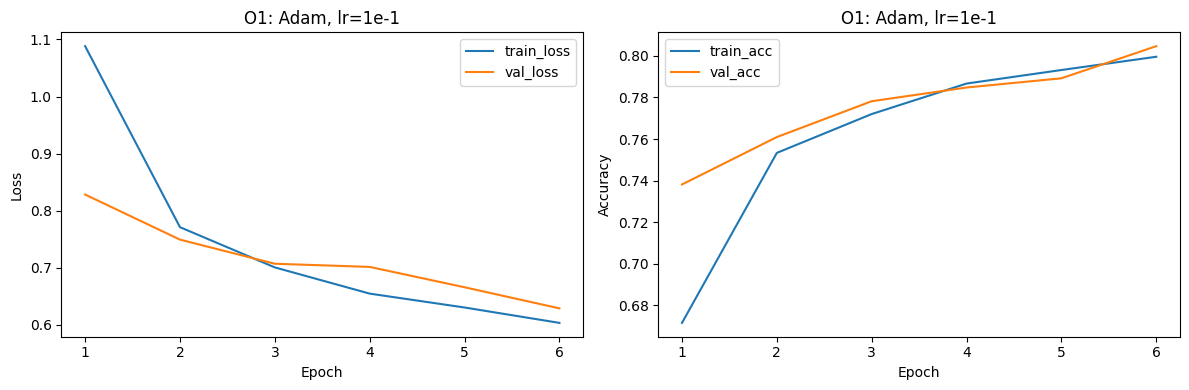

In [44]:
plot_history(o1["result"]["history"], title="O1: Adam, lr=1e-1")

In [45]:
o2 = run_experiment(
    experiment_id="O2",
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=True,
    optimizer_name="Adam",
    lr=1e-5,
    momentum=0.0,
    weight_decay=0.0,
    epochs=6,
    early_stopping=False
)

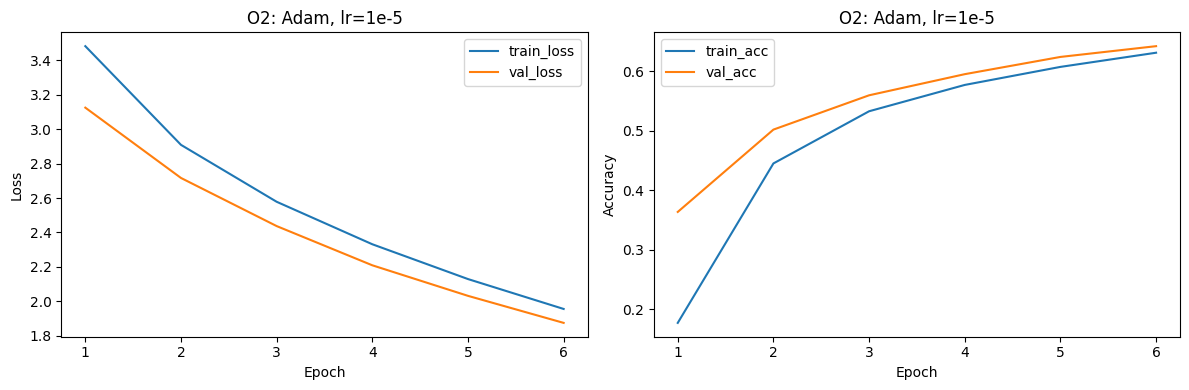

In [46]:
plot_history(o2["result"]["history"], title="O2: Adam, lr=1e-5")

In [47]:
o3 = run_experiment(
    experiment_id="O3",
    hidden_sizes=(256, 128),
    dropout=0.0,
    use_batchnorm=True,
    optimizer_name="SGD",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    epochs=12,
    early_stopping=False
)

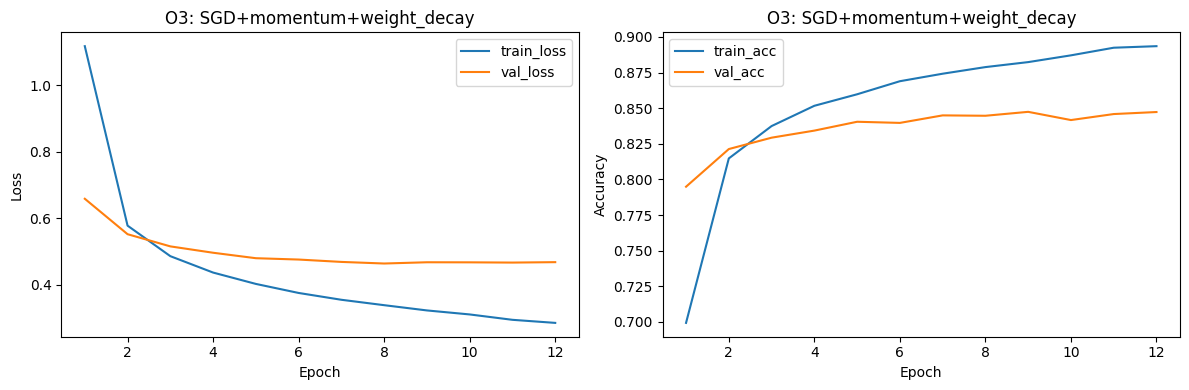

In [48]:
plot_history(o3["result"]["history"], title="O3: SGD+momentum+weight_decay")

## 49-51) Сохранение

In [49]:
[(r["experiment_id"], r["best_val_accuracy"], r["lr"], r["optimizer"]) for r in runs]

[('E1', 0.8385195035460993, 0.001, 'Adam'),
 ('E2', 0.8369237588652483, 0.001, 'Adam'),
 ('E3', 0.8490248226950354, 0.001, 'Adam'),
 ('E4', 0.8483599290780142, 0.001, 'Adam'),
 ('O1', 0.8046985815602837, 0.1, 'Adam'),
 ('O2', 0.6423758865248227, 1e-05, 'Adam'),
 ('O3', 0.8474290780141844, 0.01, 'SGD')]

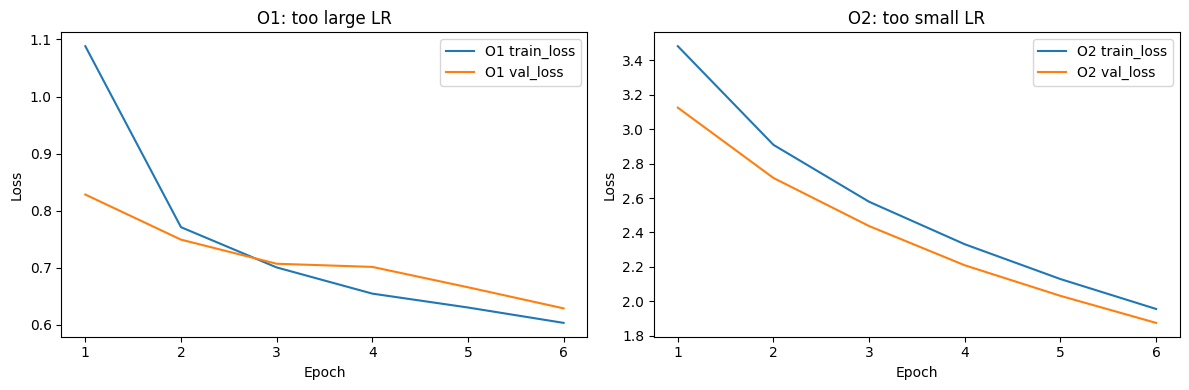

In [50]:
history_o1 = o1["result"]["history"]
history_o2 = o2["result"]["history"]

epochs_o1 = range(1, len(history_o1["train_loss"]) + 1)
epochs_o2 = range(1, len(history_o2["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_o1, history_o1["train_loss"], label="O1 train_loss")
plt.plot(epochs_o1, history_o1["val_loss"], label="O1 val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("O1: too large LR")

plt.subplot(1, 2, 2)
plt.plot(epochs_o2, history_o2["train_loss"], label="O2 train_loss")
plt.plot(epochs_o2, history_o2["val_loss"], label="O2 val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("O2: too small LR")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "curves_lr_extremes.png", bbox_inches="tight")
plt.show()

In [51]:
import csv

fieldnames = [
    "experiment_id",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "momentum",
    "weight_decay",
    "epochs_trained",
    "best_val_accuracy",
    "best_val_loss"
]

with open(ARTIFACTS_DIR / "runs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(runs)

 ## 52-54) Финальная оценка

In [52]:
runs

[{'experiment_id': 'E1',
  'dataset': 'EMNIST',
  'seed': 42,
  'model_summary': 'hidden_sizes=[256, 128], activation=ReLU, dropout=0.0, batchnorm=False',
  'optimizer': 'Adam',
  'lr': 0.001,
  'momentum': 0.0,
  'weight_decay': 0.0,
  'epochs_trained': 10,
  'best_val_accuracy': 0.8385195035460993,
  'best_val_loss': 0.48517518601518994},
 {'experiment_id': 'E2',
  'dataset': 'EMNIST',
  'seed': 42,
  'model_summary': 'hidden_sizes=[256, 128], activation=ReLU, dropout=0.3, batchnorm=False',
  'optimizer': 'Adam',
  'lr': 0.001,
  'momentum': 0.0,
  'weight_decay': 0.0,
  'epochs_trained': 10,
  'best_val_accuracy': 0.8369237588652483,
  'best_val_loss': 0.49201410332470075},
 {'experiment_id': 'E3',
  'dataset': 'EMNIST',
  'seed': 42,
  'model_summary': 'hidden_sizes=[256, 128], activation=ReLU, dropout=0.0, batchnorm=True',
  'optimizer': 'Adam',
  'lr': 0.001,
  'momentum': 0.0,
  'weight_decay': 0.0,
  'epochs_trained': 10,
  'best_val_accuracy': 0.8490248226950354,
  'best_val_l

In [53]:
test_loss, test_acc = evaluate(e4["model"], test_loader, nn.CrossEntropyLoss(), device)
test_loss, test_acc

(0.4796960370591346, 0.8460106382978724)

In [54]:
summary = {
    "best_regularized_source": best_regularized_source,
    "e4_best_val_acc": e4["result"]["best_val_acc"],
    "e4_best_val_loss": e4["result"]["best_val_loss"],
    "test_loss": test_loss,
    "test_acc": test_acc
}

summary

{'best_regularized_source': 'E3',
 'e4_best_val_acc': 0.8483599290780142,
 'e4_best_val_loss': 0.45829129671374114,
 'test_loss': 0.4796960370591346,
 'test_acc': 0.8460106382978724}